# Koopman operator learning, a toy case: Duffing oscillator

**-- PLEASE SUBMIT YOUR COMPLETED NOTEBOOK WITH CELL OUTPUTS --**


The aim of this notebook is to describe the dynamics of a non-linear dynamical system by means of the Koopman theory.

## Introduction

We consider a quantity $x \in \mathbb{R}^n$ (a vector) which evolves with time, following a dynamical system. Think for example of the joint location of the planets in our solar system, which follows the law of gravitation.

Formally, given an initial state $x(t=0) \in \mathbb{R}^n$ at time $t=0$, the time evolution of $x$ is governed by the following dynamical system:
$$
\dot{x}(t) = f(x(t)) \quad \text(1)
$$

where $\dot{x}(t) := \frac{dx(t)}{dt}$ is the temporal derivative, and $f:\mathbb{R}^n \rightarrow \mathbb{R}^n$ is a given map describing the dynamics.

For a given $f$, it is not always possible to solve the differential equation (1) analytically. For this reason, instead, numerical schemes are usually employed, to integrate in time $t$ the equation (1), so as to propagate the initial condition $x(0)$ up to a desired time $T$; think of $x(T) = x(0) + \int_{t=0}^{T} f(x(t)) dt$. The discretization in time of eq (1) or of the integral introduces numerical approximations, and yields estimates of $x(T)$ of various quality depending on the discretization scheme.

In the field of numerical simulations, discretization schemes have been studied for a long time, and numerical solvers already exist to provide good estimates of integrals (far better than with the naive discretization $x_{k+\delta} = x_k + \delta\,f(x_k)$ for a discrete time increment $\delta$, which induces a $O(\delta^2)$ error at each time step).

The goal of this practical session is to make use of such numerical solvers to improve the learning of dynamical systems with neural networks.

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import sys
from tqdm import tqdm

from torch.utils.data import TensorDataset, DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.autograd as autograd

# arrange the dataset
from sklearn.model_selection import train_test_split

## Duffing oscillator

As a toy example, we consider the Duffing oscillator, where the state $x = (x_1, x_2) \in \mathbb{R}^2$ follows the dynamical system described by the following ODEs:

$$
\dot{x}_1 = x_2\\
\dot{x}_2 = x_1 - x_1^3
$$

To integrate in time the ODEs, a 4th order Runge-Kutta scheme can be used.


In [ ]:
def duffing(array_x: np.ndarray) -> np.ndarray:
    array_dx = np.zeros(array_x.shape)
    array_dx[0] = array_x[1]
    array_dx[1] = array_x[0] - array_x[0] ** 3
    return array_dx

In [3]:
t_max = 500  # Time-horizon integration
n_iter = 5000  # Number of time steps integration
n_initial_conditions = 60  # Number of initial conditions

dim_system = 2

# Generate initial conditions
matrix_x0 = (np.random.rand(n_initial_conditions, dim_system) - 0.5) * 4
array_t = np.linspace(0, t_max, n_iter)
array3d_xt = np.zeros((matrix_x0.shape[0], matrix_x0.shape[1], n_iter))

for i in tqdm(range(matrix_x0.shape[0])):
    # Lambda function is used as solve_ivp requires a function of the form f(t, x)
    ode_result = solve_ivp(lambda _t, array_x: duffing(array_x),
                           [0, t_max],
                           matrix_x0[i],
                           method='RK45',
                           t_eval=array_t)

    array3d_xt[i, :] = ode_result.y

100%|██████████| 60/60 [00:07<00:00,  8.24it/s]


The following plot shows trajectories for different initial conditions:

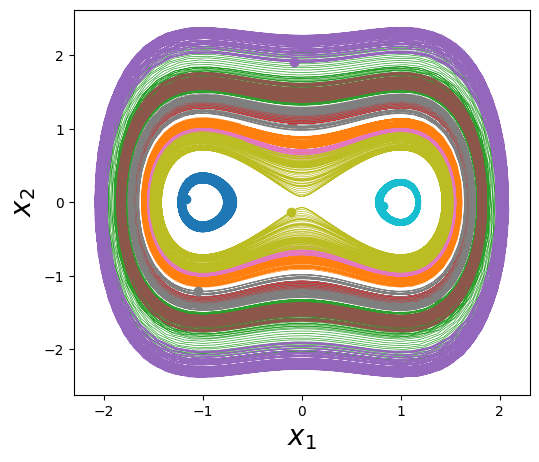

In [4]:
fig = plt.figure(figsize=(20, 5))
ax = fig.add_subplot(131)
cm = plt.get_cmap("tab10")
print(cm)
for i in range(10):
    ax.plot(array3d_xt[i, 0, :], array3d_xt[i, 1, :], lw=0.5, color=cm(i))
    ax.plot(array3d_xt[i, 0, 0], array3d_xt[i, 1, 0], 'o', lw=1.5, color=cm(i))  #initial condition
ax.set_xlabel('$x_1$', fontsize=20)
ax.set_ylabel('$x_2$', fontsize=20)
plt.show()

## The Koopman operator
### Discontinuous in time case
Given the discrete non-linear dynamical system

$$
x_{k+1} = F(x_k)
$$

where $F$ might be the $\delta$-discretised flow map of the continuous dynamical system in eq (1) given by

$$
x_{k+1} = F(x_k) := x_k + \int_{k}^{k + \delta} f(x(s))ds
$$

and $X = (x_k)_{k = 0}^N$ the discrete time series of the system state.


The _Koopman_ theory states that there exists an infinite-dimensional linear operator $\mathcal{K}$ that advances in time all observable functions $(g_i)_{i = 1}^m$ given by $g_i: \mathbb{R}^n \rightarrow \mathbb{R}$

$$
\mathcal{K} g_i(x) = g_i \circ F(x)
$$

This way, the non-linear dynamics of $x$, described by $F$, can be turned into a **linear** dynamical system, described by $\mathcal{K}$, acting on another representation space, formed by the observable quantities $g_i(x)$.

Indeed, let $g_i$ be an observable function and denoting ${g_i}_k := g_i(x_k)$, using the previous equation, the time evolution of the observables is given by

$$
{g_i}_{k+1} = g_i(x_{k+1}) = g_i(F(x_k)) = g_i \circ F(x_k) = \mathcal{K} g_i(x_k) = \mathcal{K} {g_i}_k
$$

then, the linearised dynamics of the observables is given by the following equation

$$
{g_i}_{k+1} = \mathcal{K} {g_i}_k
$$


It is then sufficient to find a function $g: \mathbb{R}^n \rightarrow \mathbb{R}^m$ with $m \gg n$ that embeds the state $x$ into a "larger enough" dimensional space $m$ such that the linear operator $\mathcal{K}$ can be inferred by a matrix $\mathbf{K} \in \mathbb{R}^{m \times m}$.

To project back the dynamics from the Koopman space ($\mathbb{R}^m$, where $g(x)$ lives) to the phase space ($\mathbb{R}^n$, where $x$ lives), a supplementary function $\varphi: \mathbb{R}^m \rightarrow \mathbb{R}^n$ is needed. Going from $x$ to the Koopman space and back yields $\varphi \text{ o  } g = $ Id.

Under this condition, the functions $g$, $\varphi$ and $\mathbf{K}$ can be parametrized $g_{\theta}$, $\varphi_{\rho}$ and $\mathbf{K}_{\phi}$, and the parameters $\theta$, $\rho$ and $\phi$ can be learned minimizing suitable loss functions.

For this purpose, given a time series $X = \{x_k | k = 1 \ldots N \}$, the following conditions hold:


1.   Reconstruction error
     $$
     \Vert \varphi_\rho (g_\theta(x_k)) - x_k  \Vert = 0
     $$
2.   Prediction error in Koopman space
     $$
     \Vert \mathbf{K_{\phi}} g_{\theta} ( x_k ) - g_{\theta} (x_{k+1})  \Vert = 0
     $$
3.   Prediction error in the phase space
     $$
     \Vert \varphi_{\rho} \left( \mathbf{K_{\phi}} g_{\theta} ( x_k )\right) - x_{k+1} \Vert = 0
     $$

The last three errors can be used as loss functions to train three different neural networks. These different neural networks compose our architecture that can be summarized as in the following sketch:



![architecture](./architecture.png)

In [5]:

# Flatten the trajectories w.r.t. initial conditions
# and only keep data in the form of (dim_system, n_iter * n_initial_conditions)
matrix_x_data = array3d_xt[:, :, :-1].swapaxes(0, 1).reshape(2, -1).T
matrix_x_next_data = array3d_xt[:, :, 1:].swapaxes(0, 1).reshape(2, -1).T

(matrix_x_data_train,
 matrix_x_data_test,
 matrix_x_next_data_train,
 matrix_x_next_data_test) = train_test_split(matrix_x_data,
                                             matrix_x_next_data,
                                             test_size=0.2)

# Cast type to float32
matrix_x_data_train = matrix_x_data_train.astype(np.float32)
matrix_x_data_test = matrix_x_data_test.astype(np.float32)
matrix_x_next_data_train = matrix_x_next_data_train.astype(np.float32)
matrix_x_next_data_test = matrix_x_next_data_test.astype(np.float32)

print(matrix_x_data_train.shape,
      matrix_x_data_test.shape,
      matrix_x_next_data_train.shape,
      matrix_x_next_data_test.shape)

(239952, 2) (59988, 2) (239952, 2) (59988, 2)


In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [7]:
torch.set_default_dtype(torch.float32)
# torch.set_default_tensor_type('torch.DoubleTensor')

batch_size = 2000  # data per batch

tensor2d_x_data_train = torch.from_numpy(matrix_x_data_train).to(device)
tensor2d_x_next_data_train = torch.from_numpy(matrix_x_next_data_train).to(device)
tensor2d_x_data_test = torch.from_numpy(matrix_x_data_test).to(device)
tensor2d_x_next_data_test = torch.from_numpy(matrix_x_next_data_test).to(device)

torch_dataset_train = TensorDataset(tensor2d_x_data_train,
                                    tensor2d_x_next_data_train)

torch_dataset_test = TensorDataset(tensor2d_x_data_test,
                                   tensor2d_x_next_data_test)

train_dataloader = DataLoader(torch_dataset_train,
                              batch_size=batch_size,
                              shuffle=True)
test_dataloader = DataLoader(torch_dataset_test,
                             batch_size=batch_size,
                             shuffle=True)

# create the models
feature_dim = 2  # dimension of the Duffing oscillator
hidden_layer = 5  # number of hidden layers in g (ENCODER) and \varphi (DECODER)
output_dim = 30  # dimension in Koopman space

In [ ]:
class Encoder(nn.Module):
    def __init__(self, list_layer_dim: list):
        super().__init__()
        self.list_layer_dim = list_layer_dim
        self.list_FC = nn.ModuleList()
        for i in range(len(self.list_layer_dim) - 1):
            input_dim = self.list_layer_dim[i]
            output_dim = self.list_layer_dim[i + 1]
            self.list_FC.append(nn.Linear(input_dim, output_dim))

    def forward(self, tensor2d_x):
        for i in range(len(self.list_layer_dim) - 2):
            tensor2d_x = F.elu(self.list_FC[i](tensor2d_x))
        return self.list_FC[-1](tensor2d_x)


In [ ]:
class Decoder(nn.Module):
    def __init__(self, list_layer_dim: list):
        super().__init__()
        self.list_layer_dim = list_layer_dim
        self.list_FC = nn.ModuleList()
        for i in range(len(self.list_layer_dim) - 1, 0, -1):
            input_dim = self.list_layer_dim[i]
            output_dim = self.list_layer_dim[i - 1]
            self.list_FC.append(nn.Linear(input_dim, output_dim))

    def forward(self, tensor2d_x: torch.Tensor):
        for i in range(len(self.list_layer_dim) - 2):
            tensor2d_x = F.elu(self.list_FC[i](tensor2d_x))
        return self.list_FC[-1](tensor2d_x)

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self, feature_dim: int, hidden_layer: int, output_dim: int):
        super().__init__()
        list_layer_dim = \
            [output_dim if i == hidden_layer
             else feature_dim + i * (output_dim - feature_dim) // hidden_layer
             for i in range(hidden_layer + 1)]
        self.encoder = Encoder(list_layer_dim)
        self.decoder = Decoder(list_layer_dim)

    def forward(self, tensor2d_x: torch.Tensor):
        tensor2d_x = self.Encoder(tensor2d_x)
        return self.Decoder(tensor2d_x)

The Koopman operator $\mathbf{K}$ (which is linear, and thus a matrix) must have a [spectral radius](https://en.wikipedia.org/wiki/Spectral_radius) $\rho(\mathbf{K})\le 1$. Such condition will provide a stable -or at least a marginally stable- Koopman operator. To fulfill this requirement, we might leverage on the Perron-Frobenius theorem.

The Perron-Frobenius th. states: if $\mathbf{K}$ is a $m \times m$ positive matrix i.e. $k_{ij} > 0$ for $1 \le i,j \le m$, then the following inequality holds:

$$
\min_i \sum_j k_{ij} \le \rho(\mathbf{K}) \le \max_i \sum_j k_{ij}
$$


**Question 1.** : Complete the `KoopmanModule` class to enforce $\rho(\mathbf{K})\le 1$, using the Perron-Frobenius theorem. Check that the initialization fulfills this property.

In [13]:
class KoopmanOperator(nn.Module):
    def __init__(self, koopman_operator_dim: int,epsilon=1e-3):
        super().__init__()
        self.koopman_operator_dim = koopman_operator_dim
        # TODO: Complete the KoopmanOperator class
        self.weight = torch.randn(output_dim, output_dim)
        self.register_parameter(name='weights', param=torch.nn.Parameter(self.weight))
        self.epsilon = epsilon

        self._normalize_weights()
    def _normalize_weights(self):
        # We calculate the row sums of the weight matrix
        row_sums = self.weight.data.sum(dim=1)
        # We find the maximum row sum
        max_row_sum = torch.max(row_sums)

        if max_row_sum > 1:
            # Finally we scale the weight matrix if the maximum row sum is greater than 1
            self.weight.data /= (max_row_sum + self.epsilon) # We add a small value to ensure it's under 1
    def forward(self, tensor2d_x: torch.Tensor):
        # First dimension of tensor2d_x is the batch size
        if tensor2d_x.shape[1] != self.koopman_operator_dim:
            sys.exit(f'Wrong Input Features. Please use tensor'
                     f' with {self.koopman_operator_dim} Input Features')
        # TODO: Implement the forward pass
        # ------------------ Constrain the weight's eigenvalues ------------------ #
        self._normalize_weights()
        # ------------------------------------------------------------------------ #
        return torch.matmul(tensor2d_x, self.weight.t().cuda())

    def check_spectral_radius(self):
        eigenvalues = torch.linalg.eigvals(self.weight.data)
        spectral_radius = torch.max(torch.abs(eigenvalues))
        return spectral_radius


dim_observable = 10
koopman_operator = KoopmanOperator(dim_observable)


In [14]:
# TODO: Check the spectrum initialisation
print("Spectral radius after initialization:", koopman_operator.check_spectral_radius().item())
eigenvalues = torch.linalg.eigvals(koopman_operator.weight.data)

Spectral radius after initialization: 0.47581878304481506


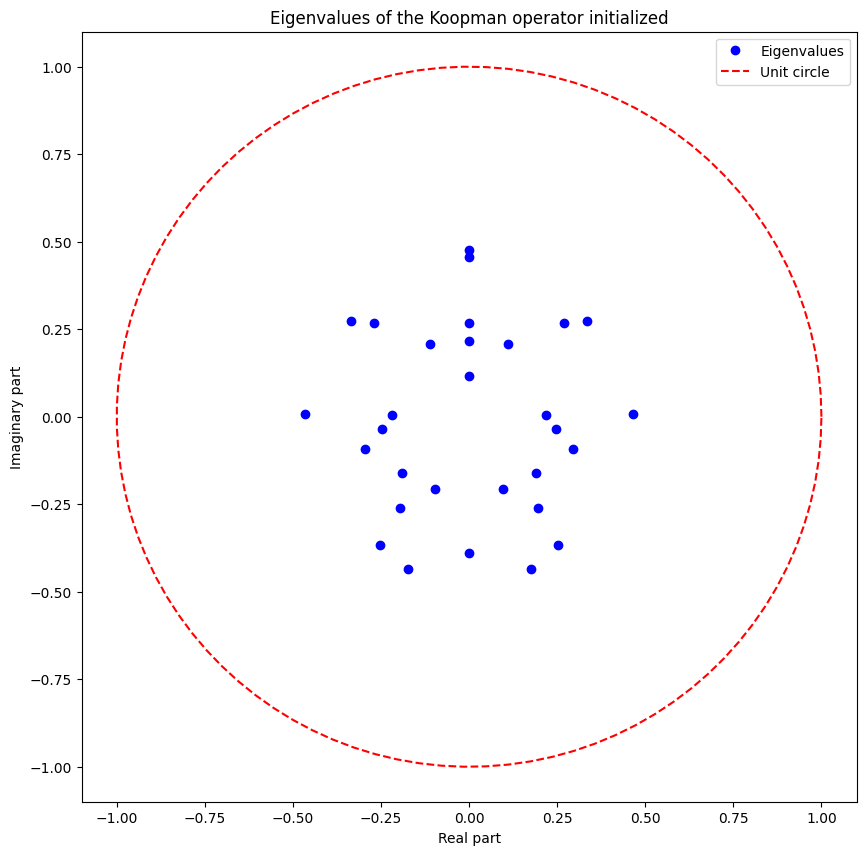

In [15]:
theta = np.linspace(0, 2*np.pi, 100)
fig= plt.figure(figsize=(10, 10))
plt.plot(np.imag(eigenvalues),np.real(eigenvalues),'o',color="b",label="Eigenvalues")

r = np.sqrt(1.0)
x1 = r*np.cos(theta)
x2 = r*np.sin(theta)
plt.plot(x1,x2,linestyle="--",label="Unit circle",color="r")

plt.xlabel("Real part")
plt.ylabel("Imaginary part")
plt.title("Eigenvalues of the Koopman operator initialized")
plt.legend()
plt.show()

In [16]:
autoencoder = Autoencoder(feature_dim, hidden_layer, output_dim).to(device)
koopman_operator = KoopmanOperator(output_dim).to(device)


In [17]:
learning_rate_autoencoder = 0.0001
learning_rate_koopman = 0.00001

optimiser_autoencoder = torch.optim.Adam(autoencoder.parameters(),
                                         lr=learning_rate_autoencoder)

optimiser_koopman = torch.optim.Adam(koopman_operator.parameters(),
                                     lr=learning_rate_koopman)

<div class="alert">   
 As shown in the plot, all the eigenvalues has a unit norm below than 1, the spectral radius remains inside the unit ball, so the normalization seems to be accurate.
 </div>

**Question 2.** : Define a function to compute the loss to be minimized. It should at least include the 3 terms listed above:
- Reconstruction error
- Prediction error in the Koopman space
- Prediction error in the phase space

Because the different objectives outlined by these losses may compete, the training can be difficult. You may try different variations on these losses and comment your findings. In order to improve the training process, one can for instance:
- Add a multiplicative factor in front of each loss component, to balance their importance; how the scales of different losses are related?
- We can refine the loss acting upon the latent space, by using a variational autoencoder approach. This is similar to the Gaussian likelihood used in the first practical (TD1). We want the prediction in the latent space (i.e. the Koopman space) to be a normal distribution $\mathcal{N}(0, 1)$ . Add a corresponding loss for the latent space. Difference to 0 mean and 1 standard deviation must be thus included in the loss;
- Freeze the gradients of one part of the network, for instance the encoder, for one specific objective, using the [`requires_grad`](https://pytorch.org/docs/stable/generated/torch.Tensor.requires_grad_.html) property. For instance:
```python
criterion = nn.MSELoss()
...
# Compute one part loss_l of the total loss
# First deactivate gradient computation for irrelevant parts of the architecture
for p in autoencoder.encoder.parameters():
    p.requires_grad = False
loss_l = criterion(pred, target)
# Restore the gradient computation
for p in autoencoder.encoder.parameters():
    p.requires_grad = True
...
total_loss = loss_1 + ... + loss_l + ...
```

<div class="alert">   
We didn't use loss_koopman and directly use LOSS in the base code as they are both really close to one another
</div>

In [18]:
# # Implement the loss function here

def LOSS(X_, Y_, X_recon, gX_, gY_, gY_pred, Y_pred, alpha1, alpha2, alpha3, alpha4):

    criterion = nn.MSELoss()

    # Freeze the encoder layers
    for p in autoencoder.encoder.parameters():
      p.requires_grad = False

    # Compute the losses
    reconst_loss = criterion(X_recon, X_)
    koopman_loss = criterion(gY_pred, gY_)
    phase_loss = criterion(Y_pred, Y_)
    vae_loss = torch.abs(torch.mean(gX_)) + torch.abs(torch.std(gX_)-1)

    # Unfreeze the encoder layers
    for p in autoencoder.encoder.parameters():
      p.requires_grad = True

    # Compute the total loss
    total_loss = alpha1 * reconst_loss + alpha2 * koopman_loss + alpha3 * phase_loss + alpha4 * vae_loss

    return total_loss, reconst_loss, koopman_loss, phase_loss, vae_loss

In [19]:
# TODO: Implement the loss function here
# # HINT: See the training process below to identify the different components of the loss
def loss_koopman(tensor2d_x: torch.Tensor,
                 tensor2d_x_next: torch.Tensor,
                 tensor2d_decoded_x: torch.Tensor,
                 tensor2d_observable_next: torch.Tensor,
                 tensor2d_koopman_observable_next: torch.Tensor,
                 tensor2d_predict_x_next: torch.Tensor):
    #TODO: implement here 
    gX_ = autoencoder.encoder(tensor2d_x)
    X_ = tensor2d_x
    Y_ = tensor2d_x_next
    X_recon = tensor2d_decoded_x
    gY_ = tensor2d_observable_next
    gY_pred = tensor2d_koopman_observable_next
    Y_pred = tensor2d_predict_x_next
    
    total_loss = LOSS(X_, Y_, X_recon, gX_, gY_, gY_pred, Y_pred,
                      0.4, 0.2, 0.2, 0.1)
    return total_loss


1.   Reconstruction error
$$
\Vert \varphi_\rho (g_\theta(x_k)) - x_k  \Vert = 0
$$
2.   Prediction error in Koopman space
$$
\Vert \mathbf{K_{\phi}} g_{\theta} ( x_k ) - g_{\theta} (x_{k+1})  \Vert = 0
$$
3.   Prediction error in the phase space
$$
\Vert \varphi_{\rho} \left( \mathbf{K_{\phi}} g_{\theta} ( x_k )\right) - x_{k+1} \Vert = 0
$$


**Question 3.**: The following cell executes the training loop. You can modify it in order to display the different intermediate losses computed in the function `LOSS` above. How do they evolve in time? Justify your final choice.

Epoch:0 - Total train loss: 0.00047277383087355584 - Reconst loss: 0.0007127362068600018 - Koopeman loss: 1.3749799236039438e-05 - Phase loss: 0.0007161472738318428 - VAE loss: 0.00041699924634494735


--------------------------------------------------------------------------------------------- TEST ---------------------------------------------------------------------------------------------
Epoch:0 - Total test loss: 0.0004618140972636036 - Reconst loss: 0.0006947091178994787 - Koopeman loss: 1.658829035978242e-05 - Phase loss: 0.0007021526689340731 - VAE loss: 0.0004018224904394885
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ 

Epoch:1 - Total train loss: 0.00045177106746558933 - Reconst loss: 0.0006763197950652386 - Koopeman loss: 2.0376313039066036e-05 - Phase loss: 0.0006924699385187336 - VAE loss: 0.00038673889536430936
Epoch:2 - Tota

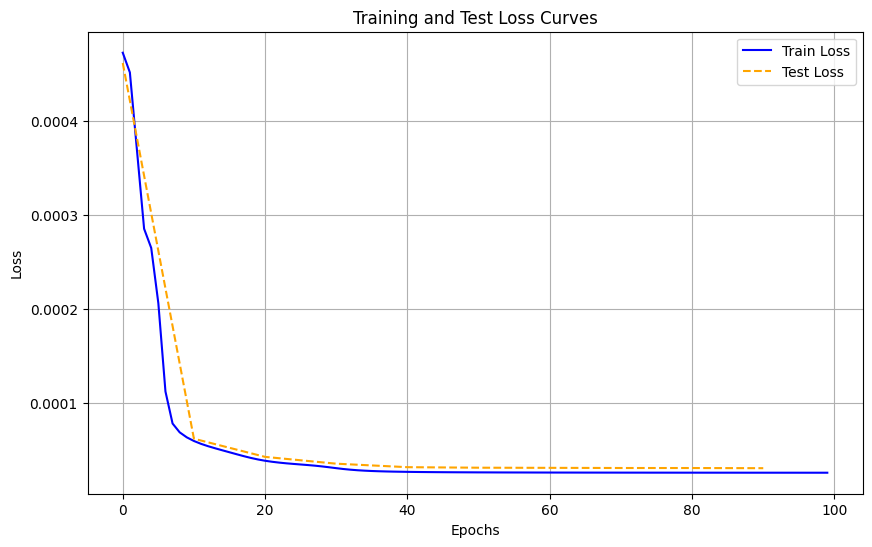

In [20]:
import time
start = time.time()
train_losses = []
test_losses = []

for epoch in range(100):
    autoencoder.train()
    koopman_operator.train()
    total_train_loss = 0
    total_loss1, total_loss2, total_loss3, total_loss4 = 0, 0, 0, 0
    for X_, Y_ in train_dataloader:
        X_, Y_ = X_.to(device), Y_.to(device)
        tensor2d_batch_x= X_.to(device)
        tensor2d_batch_x_next = Y_.to(device)
        optimiser_autoencoder.zero_grad()
        optimiser_koopman.zero_grad()


        #! 
        tensor2d_observable = autoencoder.encoder(tensor2d_batch_x)
        tensor2d_observable_next = autoencoder.encoder(tensor2d_batch_x_next)

        tensor2d_decoded_x = autoencoder.decoder(tensor2d_observable)

        tensor2d_koopman_observable_next = koopman_operator(tensor2d_observable)

        tensor2d_predict_x_next = autoencoder.decoder(tensor2d_koopman_observable_next)
        output = loss_koopman(tensor2d_batch_x,
                                       tensor2d_batch_x_next,
                                       tensor2d_decoded_x,
                                       tensor2d_observable_next,
                                       tensor2d_koopman_observable_next,
                                       tensor2d_predict_x_next)


 
        output[0].backward()
        optimiser_autoencoder.step()
        optimiser_koopman.step()

        if epoch % 1 == 0:
            total_train_loss += output[0].item() / X_.size(0) / len(train_dataloader)
            total_loss1 += output[1].item() / X_.size(0) / len(train_dataloader)
            total_loss2 += output[2].item() / X_.size(0) / len(train_dataloader)
            total_loss3 += output[3].item() / X_.size(0) / len(train_dataloader)
            total_loss4 += output[4].item() / X_.size(0) / len(train_dataloader)

    train_losses.append(total_train_loss)

    if epoch % 1 == 0:
        print(f'Epoch:{epoch} - Total train loss: {total_train_loss} - Reconst loss: {total_loss1} - Koopeman loss: {total_loss2} - Phase loss: {total_loss3} - VAE loss: {total_loss4}')

    if epoch % 10 == 0:
        autoencoder.eval()
        koopman_operator.eval()
        with torch.no_grad():
            total_test_loss = 0
            total_test_loss1 = 0
            total_test_loss2 = 0
            total_test_loss3 = 0
            total_test_loss4 = 0
            for X_, Y_ in test_dataloader:
                X_, Y_ = X_.to(device), Y_.to(device)

                gX_ = autoencoder.encoder(X_)
                gY_ = autoencoder.encoder(Y_)
                X_recon = autoencoder.decoder(gY_)
                gY_pred = koopman_operator(gX_)
                Y_pred = autoencoder.decoder(gY_pred)

                output = LOSS(X_, Y_, X_recon, gX_, gY_, gY_pred, Y_pred, 0.4, 0.2, 0.2, 0.1)
                total_test_loss += output[0].item() / X_.size(0) / len(test_dataloader)
                total_test_loss1 += output[1].item() / X_.size(0) / len(test_dataloader)
                total_test_loss2 += output[2].item() / X_.size(0) / len(test_dataloader)
                total_test_loss3 += output[3].item() / X_.size(0) / len(test_dataloader)
                total_test_loss4 += output[4].item() / X_.size(0) / len(test_dataloader)

            test_losses.append(total_test_loss)

            print('\n')
            print('-'*93, 'TEST', '-'*93)
            print(f'Epoch:{epoch} - Total test loss: {total_test_loss} - Reconst loss: {total_test_loss1} - Koopeman loss: {total_test_loss2} - Phase loss: {total_test_loss3} - VAE loss: {total_test_loss4}')
            print('-'*192,'\n')

end = time.time()
print('\n')
print('-'*192)
print(f'Time to finish : {end-start} seconds.')

# Loss curves
plt.figure(figsize=(10, 6))
plt.plot(range(len(train_losses)), train_losses, label='Train Loss', color='blue')
plt.plot(range(0, len(train_losses), 10), test_losses, label='Test Loss', color='orange', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Test Loss Curves')
plt.legend()
plt.grid(True)
plt.show()

In [21]:
# TODO: Explain the loss dynamics and justify your design choices

<div class="alert">   

We have designed a total loss function based on multiple criteria:  

The total loss is computed as a weighted sum of the reconstruction error, the prediction error in Koopman space, the prediction error in phase space, and the variational loss, which encourages predictions in Koopman space to approximate a normal distribution.  

Initially, we assigned the corresponding 0.4,0.2,0.2,0.1 weights to each components. We experimented with slight variations in these weights but observed this weights gave the best dynamics.

We opted to train the model for 100 epochs, which we found sufficient to obtain satisfactory results, as demonstrated in the verification phase. Overall, with this loss function configuration, we observed a consistent reduction in all losses on both the training and test sets.  
</div>
</div>

#### Verification

**Question 4.** : We want to ensure the Koopman operator is stable. This can be verified by checking whether its spectral radius $\rho(\mathbf{K})\le 1$. Plot the eigenvalues of the Koopman operator in order to verify the bound on its spectral radius. You can use the [`numpy.linalg.eig`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html) function to retrieve the eigenvalues of a matrix.

The magnitude of the maximum eigenvalue is: 0.41958087682724


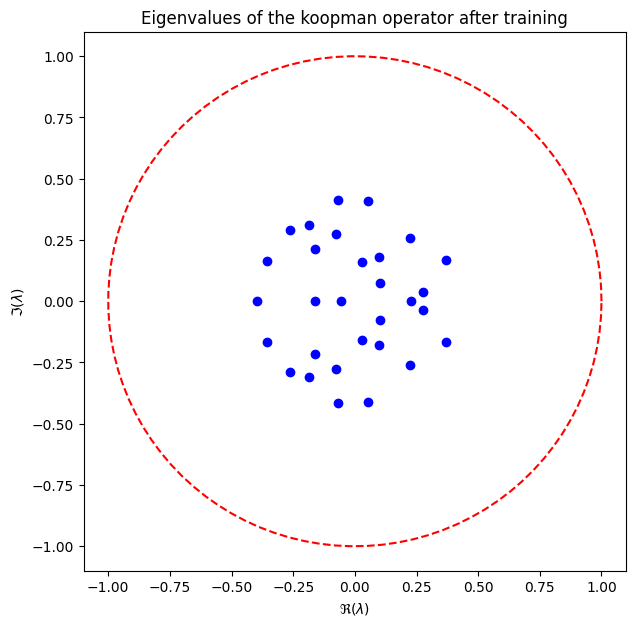

In [22]:
# TODO: Check Koopman stability and plot the eigen values of the Koopman operator against the unit circle

eigenval, _ = np.linalg.eig(koopman_operator.weight.cpu().detach().numpy())

max_eigenvalue_magnitude = max(np.abs(eigenval))
print(f"The magnitude of the maximum eigenvalue is: {max_eigenvalue_magnitude}")

plt.figure(figsize=(7, 7))
plt.scatter(np.real(eigenval), np.imag(eigenval), color='blue')
theta = np.linspace(0, 2*np.pi, 100)
r = 1  # Radius
x1 = r * np.cos(theta)
x2 = r * np.sin(theta)
plt.plot(x1, x2, color='red', linestyle='--')  # Plot circle
plt.xlabel('$\Re(\lambda)$')  # Real part of the eigenvalues
plt.ylabel('$\Im(\lambda)$')  # Imaginary part of the eigenvalues
plt.title('Eigenvalues of the koopman operator after training')
# plt.axhline(y=0, color='k', linewidth=0.5)
# plt.axvline(x=0, color='k', linewidth=0.5)
plt.show()

In [23]:
n_grid = 30
x1_min, x1_max = -2, 2
x2_min, x2_max = -2, 2

array_x1 = np.linspace(x1_min, x1_max, n_grid, dtype=np.float32)
array_x2 = np.linspace(x2_min, x2_max, n_grid, dtype=np.float32)
matrix_grid_x1, matrix_grid_x2 = np.meshgrid(array_x1, array_x2)

array3d_dynamics = np.zeros((n_grid, n_grid, 2), dtype=np.float32)

for i in range(n_grid):
    for j in range(n_grid):
        x1 = matrix_grid_x1[i, j]
        x2 = matrix_grid_x2[i, j]
        array3d_dynamics[i, j, :] = duffing(np.array([x1, x2]))

# Set evaluation mode
autoencoder.eval()
koopman_operator.eval()

array3d_dynamics_pred = np.zeros((n_grid, n_grid, 2), dtype=np.float32)

for i in range(n_grid):
    for j in range(n_grid):
        x1 = matrix_grid_x1[i, j]
        x2 = matrix_grid_x2[i, j]
        tensor2d_x = torch.tensor([[x1, x2]], dtype=torch.float32).to(device)
        tensor2d_observable = autoencoder.encoder(tensor2d_x)
        tensor2d_koopman_observable_next = koopman_operator(tensor2d_observable)
        tensor2d_predict_x_next = autoencoder.decoder(tensor2d_koopman_observable_next)
        array_x_next = tensor2d_predict_x_next.cpu().detach().numpy().ravel()

        # Here we compute a discretised version of the derivative thanks to the Koopman operator
        # and the learned encoder/decoder

        # (x_{k+1} - x_k) / \delta_t = f(x_k) is approximated by (f is duffing here)
        # (Decod(K(Encod(x_k))) - x_k) / \delta_t

        delta_time = (t_max / n_iter)
        array3d_dynamics_pred[i, j, :] = (array_x_next - [x1, x2]) / delta_time


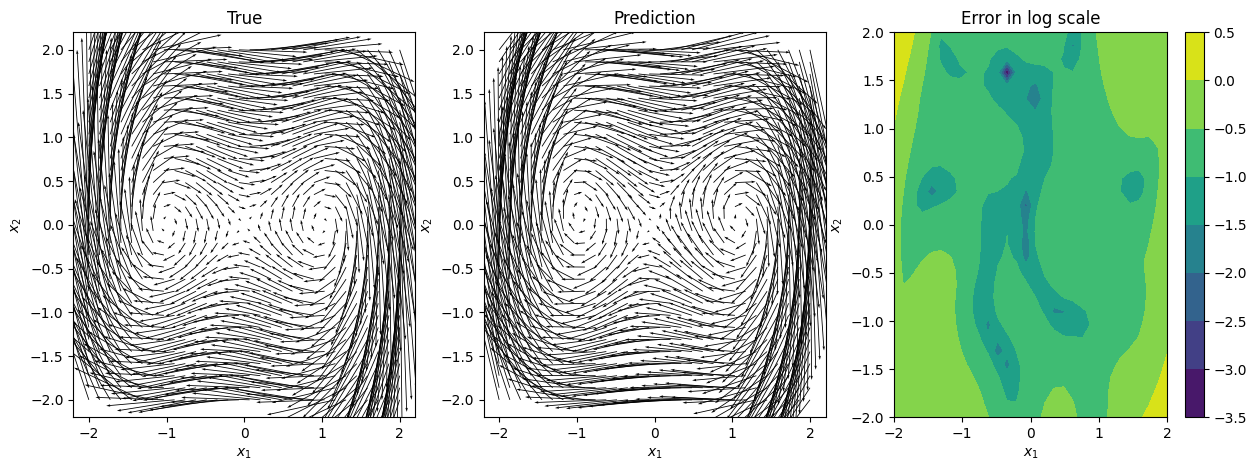

In [24]:
fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(131)
ax.quiver(matrix_grid_x1,
          matrix_grid_x2,
          array3d_dynamics[:, :, 0],
          array3d_dynamics[:, :, 1], scale=10)
ax.set_title('True')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')

ax = fig.add_subplot(132)
ax.quiver(matrix_grid_x1,
          matrix_grid_x2,
          array3d_dynamics_pred[:, :, 0],
          array3d_dynamics_pred[:, :, 1], scale=10)

ax.set_title('Prediction')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')

# Compute the error
matrix_error = np.linalg.norm(array3d_dynamics - array3d_dynamics_pred, axis=2)
matrix_error_log = np.log10(matrix_error + 1e-10)

ax = fig.add_subplot(133)
cp = ax.contourf(matrix_grid_x1,
                 matrix_grid_x2,
                 matrix_error_log)

fig.colorbar(cp)
ax.set_title('Error in log scale')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
plt.show()

<div class="alert"> The eigenvalue of the trained model are all inside the unit circle, meaning they all verify the corresponding property.
The prediction of the network are really good when sufficiently far away from the source of the two tornados; When looking close to the center of the sources, some slight variations can be found (especially on the right tornado). .  </div>

### Continuous in time case

Considering $x_k$ as the observation of a state at time $t = k \delta$, and $x_{k+1}$ the state at time $t+ \delta$, for $\delta \rightarrow 0$  it is also possible to define the continuous-time infinitesimal generator of the Koopman operator family as

$$
\mathcal{L} g (x_k)  = \lim_{\delta \rightarrow 0} \frac{\mathcal{K}g(x_k)- g(x_{k})}{\delta} = \frac{g \circ F (x_k) -x_k}{\delta}
$$

The pevious expression defines the Lie derivative, and for this reason $\mathcal{L}$ is known as the Lie operator. $\mathcal{L}$ describes the continuous dynamics of the observables in the Koopman space:

$$
\dot{g} (x) = \mathcal{L} g(x).
$$

The latter can be further expressed as:

$$
\dot{g} (x(t)) = \frac{dg(x)}{dt} = \nabla_x g \frac{dx}{dt} = \nabla_x g \cdot f(x) =\mathcal{L} g(x).
$$

Given $g_{\theta}$, $\varphi_{\rho}$ and $\mathbf{L}_{\phi}$ three parameterized functions, the following conditions hold:

1.   Reconstruction error
     $$
     \Vert \varphi_\rho (g_\theta(x)) - x  \Vert = 0
     $$
2.   Prediction error in Koopman space
     $$
     \Vert \mathbf{L_{\phi}} g_{\theta} ( x ) - \nabla g_{\theta} \cdot f(x)  \Vert = 0
     $$
3.   Prediction error in the phase space
     $$
     \Vert \varphi_{\rho} \left( \mathbf{L_{\phi}} g_{\theta} ( x )\right) - f(x) \Vert = 0
     $$

**Important Remark: As long as the system $f$ is known, the three errors can be computed without data belonging to trajectories.**

In [25]:
# Create a dataset for continuous Koopman
# with the same amount of points of the Discontinuous Koopman case
# But here no need to have continuous trajectories
matrix_x0 = (np.random.rand(n_initial_conditions * (n_iter - 1), 2) - 0.5) * 4
matrix_system_derivative_data = np.zeros(matrix_x0.shape)
for i in tqdm(range(matrix_x0.shape[0])):
    matrix_system_derivative_data[i, :] = duffing(matrix_x0[i, :])

100%|██████████| 299940/299940 [00:00<00:00, 437638.79it/s]


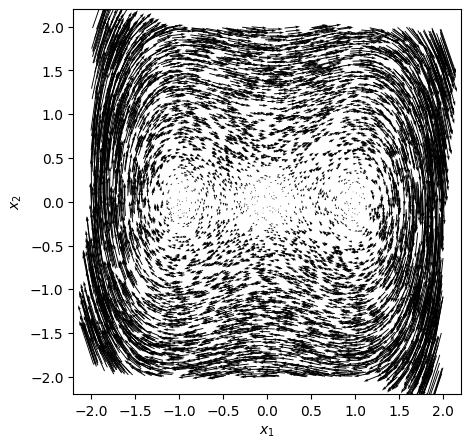

In [26]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111)
ax.quiver(matrix_x0[::50, 0],
          matrix_x0[::50, 1],
          matrix_system_derivative_data[::50, 0] * 0.2,
          matrix_system_derivative_data[::50, 1] * 0.2, scale=10)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
plt.show()

In [27]:
# create the models
feature_dim = 2  # dimension of the Duffing oscillator
hidden_layer = 5  # number of hidden layers in g (ENCODER) and \varphi (DECODER)
output_dim = 30  # dimension in Koopman space
batch_size = 2000  # data per batch

In [28]:
(matrix_x_data_train,
 matrix_x_data_test,
 matrix_x_next_data_train,
 matrix_x_next_data_test) = train_test_split(matrix_x0,
                                             matrix_system_derivative_data,
                                             test_size=0.2)

# Cast type to float32
matrix_x_data_train = matrix_x_data_train.astype(np.float32)
matrix_x_data_test = matrix_x_data_test.astype(np.float32)
matrix_x_next_data_train = matrix_x_next_data_train.astype(np.float32)
matrix_x_next_data_test = matrix_x_next_data_test.astype(np.float32)

print(matrix_x_data_train.shape,
      matrix_x_data_test.shape,
      matrix_x_next_data_train.shape,
      matrix_x_next_data_test.shape)

torch_dataset_train = TensorDataset(torch.from_numpy(matrix_x_data_train),
                                    torch.from_numpy(matrix_x_next_data_train))
torch_dataset_test = TensorDataset(torch.from_numpy(matrix_x_data_test),
                                   torch.from_numpy(matrix_x_next_data_test))

train_dataloader = DataLoader(torch_dataset_train,
                              batch_size=batch_size,
                              shuffle=True)
test_dataloader = DataLoader(torch_dataset_test,
                             batch_size=batch_size,
                             shuffle=True)

(239952, 2) (59988, 2) (239952, 2) (59988, 2)


In [29]:
class Encoder(nn.Module):
    def __init__(self, list_layer_dim):
        super().__init__()
        self.list_layer_dim = list_layer_dim
        self.list_FC = nn.ModuleList()
        for i in range(len(self.list_layer_dim) - 1):
            dim_input = self.list_layer_dim[i]
            dim_output = self.list_layer_dim[i + 1]
            self.list_FC.append(nn.Linear(dim_input, dim_output))

    def forward(self, tensor2d_x):
        for i in range(len(self.list_layer_dim) - 2):
            tensor2d_x = F.elu(self.list_FC[i](tensor2d_x))
        return self.list_FC[-1](tensor2d_x)

In [30]:
class Decoder(nn.Module):
    def __init__(self, list_layer_dim):
        super().__init__()
        self.list_layer_dim = list_layer_dim
        self.list_FC = nn.ModuleList()
        for i in range(len(self.list_layer_dim) - 1, 0, -1):
            dim_input = self.list_layer_dim[i]
            dim_output = self.list_layer_dim[i - 1]
            self.list_FC.append(nn.Linear(dim_input, dim_output))

    def forward(self, tensor2d_x):
        for i in range(len(self.list_layer_dim) - 2):
            tensor2d_x = F.elu(self.list_FC[i](tensor2d_x))
        return self.list_FC[-1](tensor2d_x)

In [31]:
class Autoencoder(nn.Module):
    def __init__(self, feature_dim, hidden_layer, output_dim):
        super().__init__()

        list_layer_dim = \
            [output_dim if i == hidden_layer
             else feature_dim + i * (output_dim - feature_dim) // hidden_layer
             for i in range(hidden_layer + 1)]

        self.encoder = Encoder(list_layer_dim)
        self.decoder = Decoder(list_layer_dim)

    def forward(self, tensor2d_x: torch.Tensor):
        tensor2d_x = self.encoder(tensor2d_x)
        return self.decoder(tensor2d_x)

The Lie operator must be defined such that it will be always stable by construction.
To do that, we consider a matrix of parameters $\Psi \in \mathbb{R}^{m \times m}$ and a vector of parameters $\Gamma \in \mathbb{R}^m$. The resulting Lie operator will be of the form:

$$
\mathbf{L} = (\Psi - \Psi^T) - \text{diag}(\vert \Gamma \vert)
$$

with eigenvalues whose real part $\Re(\lambda) \leq 0$ .
See https://math.stackexchange.com/questions/952233/eigenvalues-of-the-sum-of-a-diagonal-matrix-and-a-skew-symmetric-matrix for the mathematical proof (identify the matrix). Moreover if $\lambda \in \mathbb{C}$ is an eigenvalue of $\mathbf{L}$, it turns out that its real part $\Re(\lambda) \propto \Vert \Gamma \Vert$, i.e. it only depends on $\Gamma$.

Remark: $- \text{diag}(\vert \Gamma \vert)$ is always a diagonal matrix with non-positive elements.


**Question 4.** : As you did for the discrete case, you now have to implement the `LieModule` module. It should have the form indicated above to guarantee $\Re(\lambda) \leq 0$. Check that the initialization fulfills this property.

In [32]:
class LieModule(nn.Module):
    def __init__(self, lie_operator_dim: int):
        super().__init__()
        self.lie_operator_dim = lie_operator_dim
        # TODO: Complete function
        # Initialize Psi
        self.Psi = nn.Parameter(torch.randn(lie_operator_dim, lie_operator_dim))
        # Initialize Gamma
        self.Gamma = nn.Parameter(torch.randn(lie_operator_dim))

        self.lie_init = self.Psi - self.Psi.t() - torch.diag(torch.abs(self.Gamma))

    def forward(self, tensor2d_x: torch.Tensor):
        if tensor2d_x.shape[1] != self.lie_operator_dim:
            sys.exit(f'Wrong Input Features. Please use tensor'
                     f' with {self.koopman_operator_dim} Input Features')

        # TODO: Implement forward
        # Compute the Lie operator L
        Psi_skew = self.Psi - self.Psi.t()
        Gamma_diag = torch.diag(torch.abs(self.Gamma))
        L = Psi_skew - Gamma_diag

        # Apply the Lie operator to the input tensor
        result = torch.mm(tensor2d_x, L)

        return result, L

In [33]:
autoencoder = Autoencoder(feature_dim, hidden_layer, output_dim).to(device)
lie_operator = LieModule(output_dim).to(device)
print(autoencoder)

Autoencoder(
  (encoder): Encoder(
    (list_FC): ModuleList(
      (0): Linear(in_features=2, out_features=7, bias=True)
      (1): Linear(in_features=7, out_features=13, bias=True)
      (2): Linear(in_features=13, out_features=18, bias=True)
      (3): Linear(in_features=18, out_features=24, bias=True)
      (4): Linear(in_features=24, out_features=30, bias=True)
    )
  )
  (decoder): Decoder(
    (list_FC): ModuleList(
      (0): Linear(in_features=30, out_features=24, bias=True)
      (1): Linear(in_features=24, out_features=18, bias=True)
      (2): Linear(in_features=18, out_features=13, bias=True)
      (3): Linear(in_features=13, out_features=7, bias=True)
      (4): Linear(in_features=7, out_features=2, bias=True)
    )
  )
)


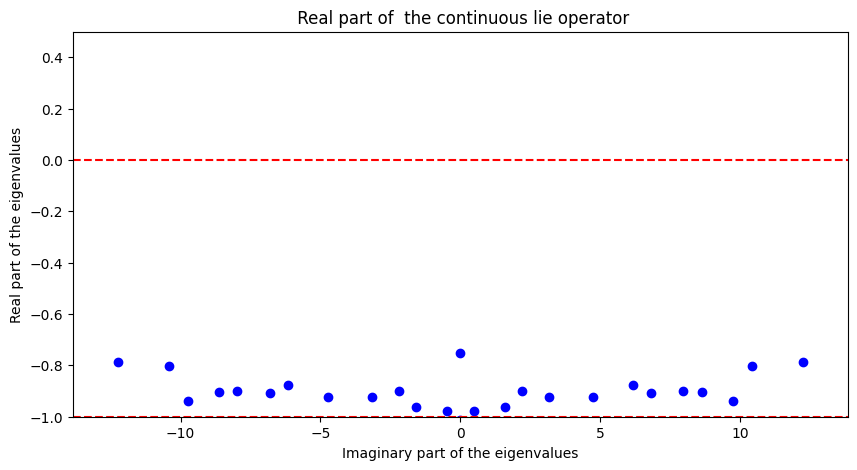

In [34]:

# Check that Re(\lambda) <= 0 at initialisation

eigenval, _ = np.linalg.eig(lie_operator.lie_init.cpu().detach().numpy())

fig, ax = plt.subplots(figsize=(10, 5))

# Plot the eigenvalues
plt.scatter(np.imag(eigenval), np.real(eigenval), color='blue')

ax.axhline(y=0, linestyle='--', color ='r')
ax.axhline(y=-1, linestyle='--', color ='r')
plt.ylim(-1,0.5)
ax.set_ylabel('$\lambda$')

plt.title(' Real part of  the continuous lie operator')
plt.xlabel('Imaginary part of the eigenvalues')
plt.ylabel('Real part of the eigenvalues')
plt.show()

<div class="alert">   
All Eigenvalue have indeed a negative real part. This confirms the dynamics of the model.
</div>

Some tricks are needed to train. If the autoencoder and the Lie model are learned at the same speed, the training turns out to be highly unstable since the three loss functions have moving targets. For this reason, the Lie learning rate has been chosen smaller than the autoencoder one.

In [35]:
learning_rate_autoencoder = 0.0001
learning_rate_lie = 0.00001

optimiser_autoencoder = torch.optim.Adam(autoencoder.parameters(),
                                         lr=learning_rate_autoencoder,
                                         weight_decay=1e-3)
optimiser_lie = torch.optim.Adam(lie_operator.parameters(),
                                 lr=learning_rate_lie,
                                 weight_decay=1e-3)

A further loss is considered to stabilize the learning stage. The state $x$ belongs to a compact set, since it is the solution of a dissipative dynamical system. This is not true for $g(x)$ (we need to choose appropriate activation functions to have appropriate Liptchitz guarantees). To avoid discrepancies in magnitudes of $g_i(x)$, a regularization loss is added:

$$
\mu = \frac{1}{m} \sum_m g_i(x) = 0  \quad \text{and} \quad  \sigma = \left( \frac{1}{m}\sum_m(g_i(x)-\mu)^2 \right)^{1/2} = 1
$$

inspired by VAE.

For the training to be smooth, the encoder parameters are not affected by the **prediction loss in phase space**. This is based on an empirical observation and is motivated by the fact that the encoder appears in the three losses and plays a competitive role against the decoder and the Lie model. This should not affect the results since the encoder remains coupled with the decoder in the **reconstruction loss** and with the Lie operator in the **prediction loss in Koopman space**.

**Question 5.** : Implement the loss function similarly to what you did for the **Question 2.** Note that here you should use the dynamics $f$ and its values for a set of points belonging to the domain $\left[ -2, 2 \right]^2$ while no data from proper **trajectories** are needed.

In [36]:
# Implement the loss function here
# See the training process below to identify the different components of the loss
def loss(tensor2d_x: torch.Tensor,
         tensor2d_x_next: torch.Tensor,
         tensor2d_decoded_x: torch.Tensor,
         tensor2d_observable_next: torch.Tensor,
         tensor2d_lie_observable_next: torch.Tensor,
         tensor2d_predict_x_next: torch.Tensor,
         tensor2d_jvp: torch.Tensor):

   # TODO: Implement loss

    # We follow the same procedure than for Question 2
    criterion = nn.MSELoss()


    recon_loss = criterion(tensor2d_decoded_x, tensor2d_x)
    lie_loss = criterion(tensor2d_lie_observable_next, tensor2d_observable_next)
    # add the new loss
    variational_loss = torch.abs(torch.mean(tensor2d_observable)) + torch.abs(torch.std(tensor2d_observable)-1) # We follow the hint

    for p in autoencoder.encoder.parameters():
      p.requires_grad = False

    phase_loss = criterion(tensor2d_predict_x_next, tensor2d_x_next)

    for p in autoencoder.encoder.parameters():
      p.requires_grad = True


    # We finally compute the total loss
    total_loss = 0.9 * recon_loss + 0.02 * lie_loss + 0.4 * phase_loss + 0.9 * variational_loss

    return total_loss, recon_loss, lie_loss, phase_loss, variational_loss

<div class="alert">
In this section, we assigned different weights to each component. This wieght gave the best results.
 </div>

**Since trajectories are not needed**, random states can be sampled from the system manifold $x_1 \in [-2, 2]$, $x_2 \in [-2, 2]$.

In [37]:
n_batch = len(train_dataloader)
n_epoch = 100 # To be tuned

for epoch in range(n_epoch):
    autoencoder.train()
    lie_operator.train()
    total_train_loss = 0
    total_loss1, total_loss2, total_loss3, total_loss4 = 0, 0, 0, 0
    for tensor2d_batch_x, tensor2d_batch_x_next in train_dataloader:
        tensor2d_batch_x = tensor2d_batch_x.to(device)
        tensor2d_batch_x_next = tensor2d_batch_x_next.to(device)

        optimiser_autoencoder.zero_grad()
        optimiser_lie.zero_grad()

        # dgX = lie_operator * gX
        # jvp = \nabla_x g (x) * f(x) (jvp: jacobian vector product)
        (tensor2d_observable, tensor2d_jvp) = \
            autograd.functional.jvp(autoencoder.encoder,
                                    tensor2d_batch_x,
                                    tensor2d_batch_x_next,
                                    create_graph=True)

        tensor2d_decoded_x = autoencoder.decoder(tensor2d_observable)

        tensor2d_lie_observable_next, lie_matrix = lie_operator(tensor2d_observable)
        tensor2d_predict_x_next = autoencoder.decoder(tensor2d_lie_observable_next)

        tensor_loss_val = \
            loss(tensor2d_x=tensor2d_batch_x,
                 tensor2d_x_next=tensor2d_batch_x_next,
                 tensor2d_decoded_x=tensor2d_decoded_x,
                 tensor2d_observable_next=tensor2d_observable,
                 tensor2d_lie_observable_next=tensor2d_lie_observable_next,
                 tensor2d_predict_x_next=tensor2d_predict_x_next,
                 tensor2d_jvp=tensor2d_jvp)

        tensor_loss_val[0].backward()
        optimiser_autoencoder.step()
        optimiser_lie.step()

        if epoch % 1 == 0:
            total_train_loss += tensor_loss_val[0].item()
    if epoch % 1 == 0:
        print(epoch, total_train_loss)

    if epoch % 10 == 0:
        autoencoder.eval()
        lie_operator.eval()
        with torch.no_grad():
            total_test_loss = 0
            total_loss1, total_loss2, total_loss3, total_loss4 = 0, 0, 0, 0
            for tensor2d_batch_x, tensor2d_batch_x_next in test_dataloader:
                tensor2d_batch_x = tensor2d_batch_x.to(device)
                tensor2d_batch_x_next = tensor2d_batch_x_next.to(device)

                (tensor2d_observable, tensor2d_jvp) = \
                    autograd.functional.jvp(autoencoder.encoder,
                                            tensor2d_batch_x,
                                            tensor2d_batch_x_next,
                                            create_graph=True)
                tensor2d_decoded_x = autoencoder.decoder(tensor2d_observable)

                tensor2d_lie_observable_next, lie_matrix = lie_operator(tensor2d_observable)
                tensor2d_predict_x_next = autoencoder.decoder(tensor2d_lie_observable_next)

                tensor_loss_val = \
                    loss(tensor2d_x=tensor2d_batch_x,
                         tensor2d_x_next=tensor2d_batch_x_next,
                         tensor2d_decoded_x=tensor2d_decoded_x,
                         tensor2d_observable_next=tensor2d_observable,
                         tensor2d_lie_observable_next=tensor2d_lie_observable_next,
                         tensor2d_predict_x_next=tensor2d_predict_x_next,
                         tensor2d_jvp=tensor2d_jvp)

                total_test_loss += tensor_loss_val[0].item()
            print('-' * 50, 'TEST', '-' * 50)
            print(epoch, total_test_loss)
            print('-' * 106)

0 373.243812084198
-------------------------------------------------- TEST --------------------------------------------------
0 88.92244505882263
----------------------------------------------------------------------------------------------------------
1 329.1367332935333
2 256.6732004880905
3 196.35022115707397
4 149.61695325374603
5 112.86036282777786
6 92.41275489330292
7 79.52396941184998
8 67.1585340499878
9 54.69299691915512
10 44.90924572944641
-------------------------------------------------- TEST --------------------------------------------------
10 10.24055477976799
----------------------------------------------------------------------------------------------------------
11 38.48373046517372
12 34.062872141599655
13 30.5667677372694
14 27.73711784183979
15 25.250205382704735
16 23.33634762465954
17 21.757744789123535
18 20.370777755975723
19 19.07019454240799
20 17.93500043451786
-------------------------------------------------- TEST ----------------------------------------


### Verification

**Question 6.** : As in the **Question 3.** we want to ensure the Lie operator is stable. This can be verified by checking that the real part of the eigenvalues is negative. Plot the relevant eigenvalues of the Lie operator. You can use the [`numpy.linalg.eig`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html) function to retrieve the eigenvalues of a matrix.

In [38]:
# TODO: Check the eigenvalues real part
# lie_matrix = lie_operator(tensor2d_observable)

eigenval, _ = np.linalg.eig(lie_matrix.cpu().detach().numpy())
print(max(np.real(eigenval)))


-0.6412433


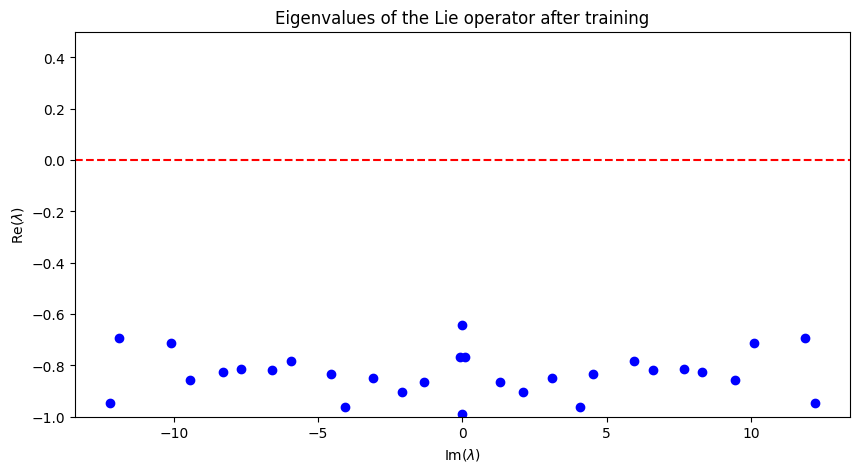

In [39]:
# TODO: Plot the eigenvalues
fig, ax = plt.subplots(figsize=(10, 5))

plt.scatter(np.imag(eigenval), np.real(eigenval), color='blue')
ax.axhline(y=0, linestyle='--', color ='r')
plt.ylim(-1,0.5)
# ax.set_xticks(ticks=np.arange(len(eigenval)))
ax.set_ylabel('$\lambda$')

plt.title('Eigenvalues of the Lie operator after training')
plt.xlabel("Im($\lambda$)")
plt.ylabel("Re($\lambda$)")
plt.show()

<div class="alert">   
The eigenvalue of the trained Lie operator still have negative real part.  This is the desired property
</div>

In [40]:

n_grid = 30
array_x1 = np.linspace(x1_min, x1_max, n_grid, dtype=np.float32)
array_x2 = np.linspace(x2_min, x2_max, n_grid, dtype=np.float32)
matrix_grid_x1, matrix_grid_x2 = np.meshgrid(array_x1, array_x2)

array3d_dynamics = np.zeros((n_grid, n_grid, 2))

for i in range(n_grid):
    for j in range(n_grid):
        array3d_dynamics[i, j, :] = duffing(np.array([matrix_grid_x1[i, j], matrix_grid_x2[i, j]]))

autoencoder.eval()
lie_operator.eval()
array3d_dynamics_pred = np.zeros((n_grid, n_grid, 2))
for i in range(n_grid):
    for j in range(n_grid):
        x1 = matrix_grid_x1[i, j]
        x2 = matrix_grid_x2[i, j]
        tensor2d_x = torch.tensor([[x1, x2]], dtype=torch.float32).to(device)
        tensor2d_observable = autoencoder.encoder(tensor2d_x)
        tensor2d_lie_observable_next = lie_operator(tensor2d_observable)[0]
        tensor2d_predict_x_next = autoencoder.decoder(tensor2d_lie_observable_next)
        array_x_next = tensor2d_predict_x_next.cpu().detach().numpy().ravel()
        array3d_dynamics_pred[i, j, :] = array_x_next

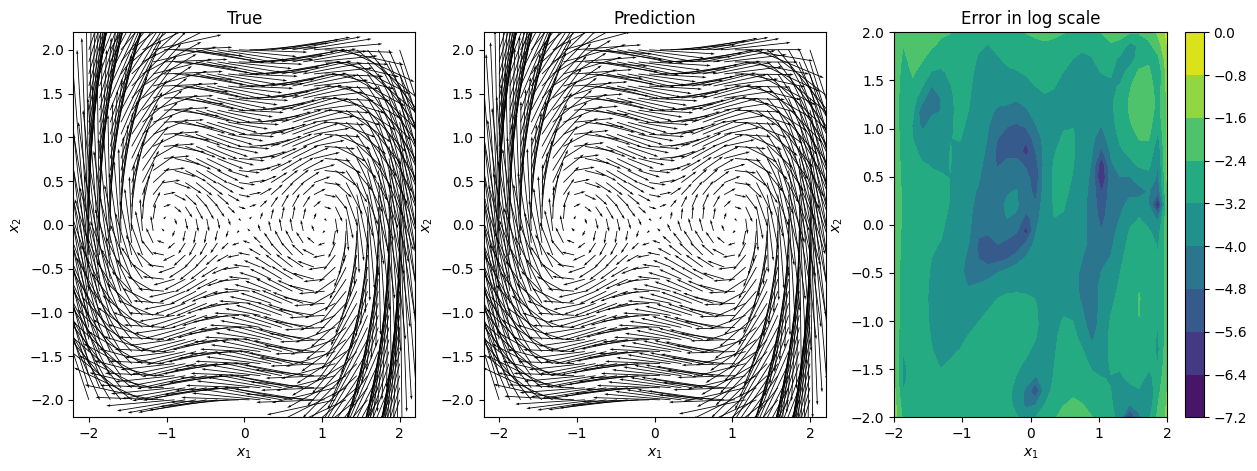

In [41]:
fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(131)
ax.quiver(matrix_grid_x1, matrix_grid_x2, array3d_dynamics[:, :, 0], array3d_dynamics[:, :, 1], scale=10)
ax.set_title('True')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')

ax = fig.add_subplot(132)
ax.quiver(matrix_grid_x1, matrix_grid_x2, array3d_dynamics_pred[:, :, 0], array3d_dynamics_pred[:, :, 1], scale=10)
ax.set_title('Prediction')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')

ax = fig.add_subplot(133)
cp = ax.contourf(matrix_grid_x1, matrix_grid_x2,
                 np.log(np.linalg.norm(array3d_dynamics - array3d_dynamics_pred, axis=2)))
fig.colorbar(cp)
ax.set_title('Error in log scale')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')

plt.show()

<div class="alert">  The prediction are visually close to the ground Truth. Some difference can be seen on the left Tornado.  The dynamic close and far from the sources are really similar to the ground truth. Looking at the error on a log scale makes the error lower than it previously was even on the boundaries of the plot, meaning that the approach is more efficient to deal with these vector flows.
 </div>


**Question 7.** : Compare and comment below the two approaches (discrete vs continuous operator).

Summary of what we have done:
<div class="alert">
We investigated two methodologies for modeling nonlinear systems using Koopman theory within a deep learning framework, focusing on both discrete and continuous formulations:  

- **Discrete Approach:**  
  In this case, we employed the Koopman operator in conjunction with an autoencoder to map the system dynamics into a high-dimensional latent space. To ensure stability, we imposed a constraint on the spectral radius of the Koopman matrix, ensuring it remained below 1. This was achieved by leveraging the upper bound from the Perron-Frobenius theorem.  
  The model was trained using four distinct loss functions with different weighting. We emphasized the reconstruction error to have more accurate results.

- **Continuous Approach:**  
  This method relied on the Lie operator rather than the Koopman operator. Stability was maintained by ensuring that the eigenvalues of the Lie matrix were negative. The same four loss functions were applied, but with different weight distributions to prioritize certain components.  

### Comparison of the Two Approaches  

Our analysis showed that the **continuous operator outperformed the discrete operator**. This conclusion is supported by log error heatmaps, which demonstrate lower errors in the continuous case, indicating a more accurate approximation of the system.  

Both models were trained for **100 epochs**, with execution times ranging between **5:30 min and 6 min** on CUDA.  

</div>

**-- PLEASE SUBMIT YOUR COMPLETED NOTEBOOK WITH CELL OUTPUTS --**